# Notebook 03 — Prototipo SAM3 con detectores externos + texto directo

Este notebook prueba **SAM3** sobre el mismo frame preprocesado del notebook 01. La diferencia con el [notebook 02](02_sam2_prototipo.ipynb) (que usa SAM2) son **dos cosas**:

1. SAM3 segmenta con un encoder más nuevo y multi-instancia.
2. SAM3 **acepta prompts de texto directamente** — es decir, internaliza un detector y no necesita Grounding DINO adelante.

## Pipeline de los 3 enfoques

```
Enfoque A:  frame  →  blob_log         →  puntos  →  SAM3  →  máscaras
Enfoque B:  frame  →  Grounding DINO   →  cajas   →  SAM3  →  máscaras
Enfoque C:  frame  →                       SAM3 (con texto directo)  →  máscaras
                                       (detector + segmentador en uno)
```

Los enfoques A y B son **idénticos al notebook 02**, sólo cambia el segmentador (SAM2 → SAM3). El **C es exclusivo de SAM3** y es donde vamos a ver el verdadero salto.

## ¿Qué cambió SAM3 vs SAM2?

| Aspecto                                     | SAM2 (2024) | SAM3 (2025)   |
| ------------------------------------------- | ----------- | ------------- |
| Prompts visuales (puntos, cajas, máscaras)  | ✅          | ✅            |
| Prompts de texto abierto                    | ❌          | ✅            |
| Detección + segmentación en una sola pasada | ❌          | ✅            |
| Tracking en video                           | ✅          | ✅ (mejorado) |

## Importante: SAM3 es gated

Hay que tener acceso aprobado en https://huggingface.co/facebook/sam3 y haberse autenticado en la máquina con `uv run huggingface-cli login`. Si la celda de carga falla con `OSError`, es probable que el acceso no esté aprobado todavía.


---

## Setup

Mismo arranque que el notebook 02: cargamos un frame, lo pasamos por el pipeline de preprocesamiento.


In [1]:
import sys
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image

sys.path.append(str(Path("..") / "src"))
from axonal_tracking.ets_reader import encontrar_ets, leer_header_ets, leer_frame
from axonal_tracking import preprocesamiento as pp
from axonal_tracking import visualizacion as viz

# Device
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Device: {device}")

# Rutas
VIDEOS = Path("/Users/alejandrovalle/Desktop/Videos-Kymos-experimental data")
VIDEO = VIDEOS / "Ex" / "Movie_674.vsi"
ROI = VIDEO.parent / f'{VIDEO.stem.replace("Movie_", "")}.roi'
FRAME_IDX = 0

ets = encontrar_ets(VIDEO)
info = leer_header_ets(ets)
frame_u16 = leer_frame(info, FRAME_IDX)

ruta_roi = ROI if ROI.exists() else None
pasos = pp.pipeline_frame(frame_u16, ruta_roi=ruta_roi)
frame_rgb = pasos["rgb_uint8"]
frame_pil = Image.fromarray(frame_rgb)
frame_limpio = pasos["sin_ruido"]

print(f"Frame listo: shape={frame_rgb.shape}, dtype={frame_rgb.dtype}")

Device: mps
Frame listo: shape=(1148, 1279, 3), dtype=uint8


---

## Carga del modelo SAM3

La primera carga descarga varios GB. Tarda unos minutos.


In [2]:
from transformers import Sam3Processor, Sam3Model

MODEL_ID = "facebook/sam3"
print(f"Cargando {MODEL_ID}...")
processor_sam3 = Sam3Processor.from_pretrained(MODEL_ID)
model_sam3 = Sam3Model.from_pretrained(MODEL_ID).to(device).eval()
n_params = sum(p.numel() for p in model_sam3.parameters()) / 1e6
print(f"OK — SAM3 cargado en {device} ({n_params:.0f} M parametros)")

Cargando facebook/sam3...


Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

OK — SAM3 cargado en mps (840 M parametros)


---

## Enfoque A — blob_log + SAM3 (cajas a partir de blobs)

Igual que en el notebook 02 a nivel conceptual: detector clásico LoG → SAM3 segmenta lo que está en cada candidato. **Diferencia técnica importante:** SAM3 **no acepta `input_points`** como prompts, sólo `input_boxes`. Es un cambio de API respecto a SAM2.

Solución: para cada blob `(y, x, σ)` que devuelve `blob_log`, construimos una caja chiquita centrada en `(x, y)` con radio `≈ σ·√2 + padding`. Eso convierte cada blob en una bounding box que SAM3 sí acepta. El resultado conceptualmente es lo mismo — segmentar el objeto que está alrededor de la posición detectada.


In [3]:
from skimage.feature import blob_log

f_norm = frame_limpio / frame_limpio.max() if frame_limpio.max() > 0 else frame_limpio
blobs = blob_log(f_norm, min_sigma=1, max_sigma=3, num_sigma=5, threshold=0.05)

N_MAX = 30
intensidades = np.array([frame_limpio[int(y), int(x)] for y, x, _ in blobs])
orden = np.argsort(intensidades)[::-1][:N_MAX]
blobs_top = blobs[orden]
print(
    f"blob_log: {len(blobs)} blobs totales, pasamos los {len(blobs_top)} mas intensos a SAM3."
)

# A diferencia de SAM2, SAM3 NO acepta input_points: solo input_boxes.
# Convertimos cada blob en una caja chiquita centrada en (x,y) con radio = sigma + padding.
H, W = frame_rgb.shape[:2]


def blob_a_caja(y, x, sigma, padding=2):
    r = max(sigma * np.sqrt(2) + padding, 3.0)
    return [
        max(float(x - r), 0.0),
        max(float(y - r), 0.0),
        min(float(x + r), float(W - 1)),
        min(float(y + r), float(H - 1)),
    ]


cajas_blobs = [blob_a_caja(y, x, s) for y, x, s in blobs_top]
input_boxes_a = [cajas_blobs]  # 3 niveles: [imagen, objeto, [x1,y1,x2,y2]]

inputs_a = processor_sam3(
    images=frame_pil,
    input_boxes=input_boxes_a,
    return_tensors="pt",
).to(device)

with torch.no_grad():
    outputs_a = model_sam3(**inputs_a)

# SAM3 no tiene post_process_masks; todo va por post_process_instance_segmentation.
resultados_a = processor_sam3.post_process_instance_segmentation(
    outputs_a,
    threshold=0.0,  # no filtramos por score, queremos una mascara por caja
    target_sizes=[(frame_pil.size[1], frame_pil.size[0])],
)[0]

m_arr_a = resultados_a.get("masks", None)
if m_arr_a is not None and hasattr(m_arr_a, "cpu"):
    m_arr_a = m_arr_a.cpu().numpy()
elif m_arr_a is None:
    m_arr_a = np.zeros((0, *frame_rgb.shape[:2]), dtype=bool)

print(f"SAM3 devolvio {len(m_arr_a)} mascaras.")

blob_log: 80 blobs totales, pasamos los 30 mas intensos a SAM3.
SAM3 devolvio 200 mascaras.


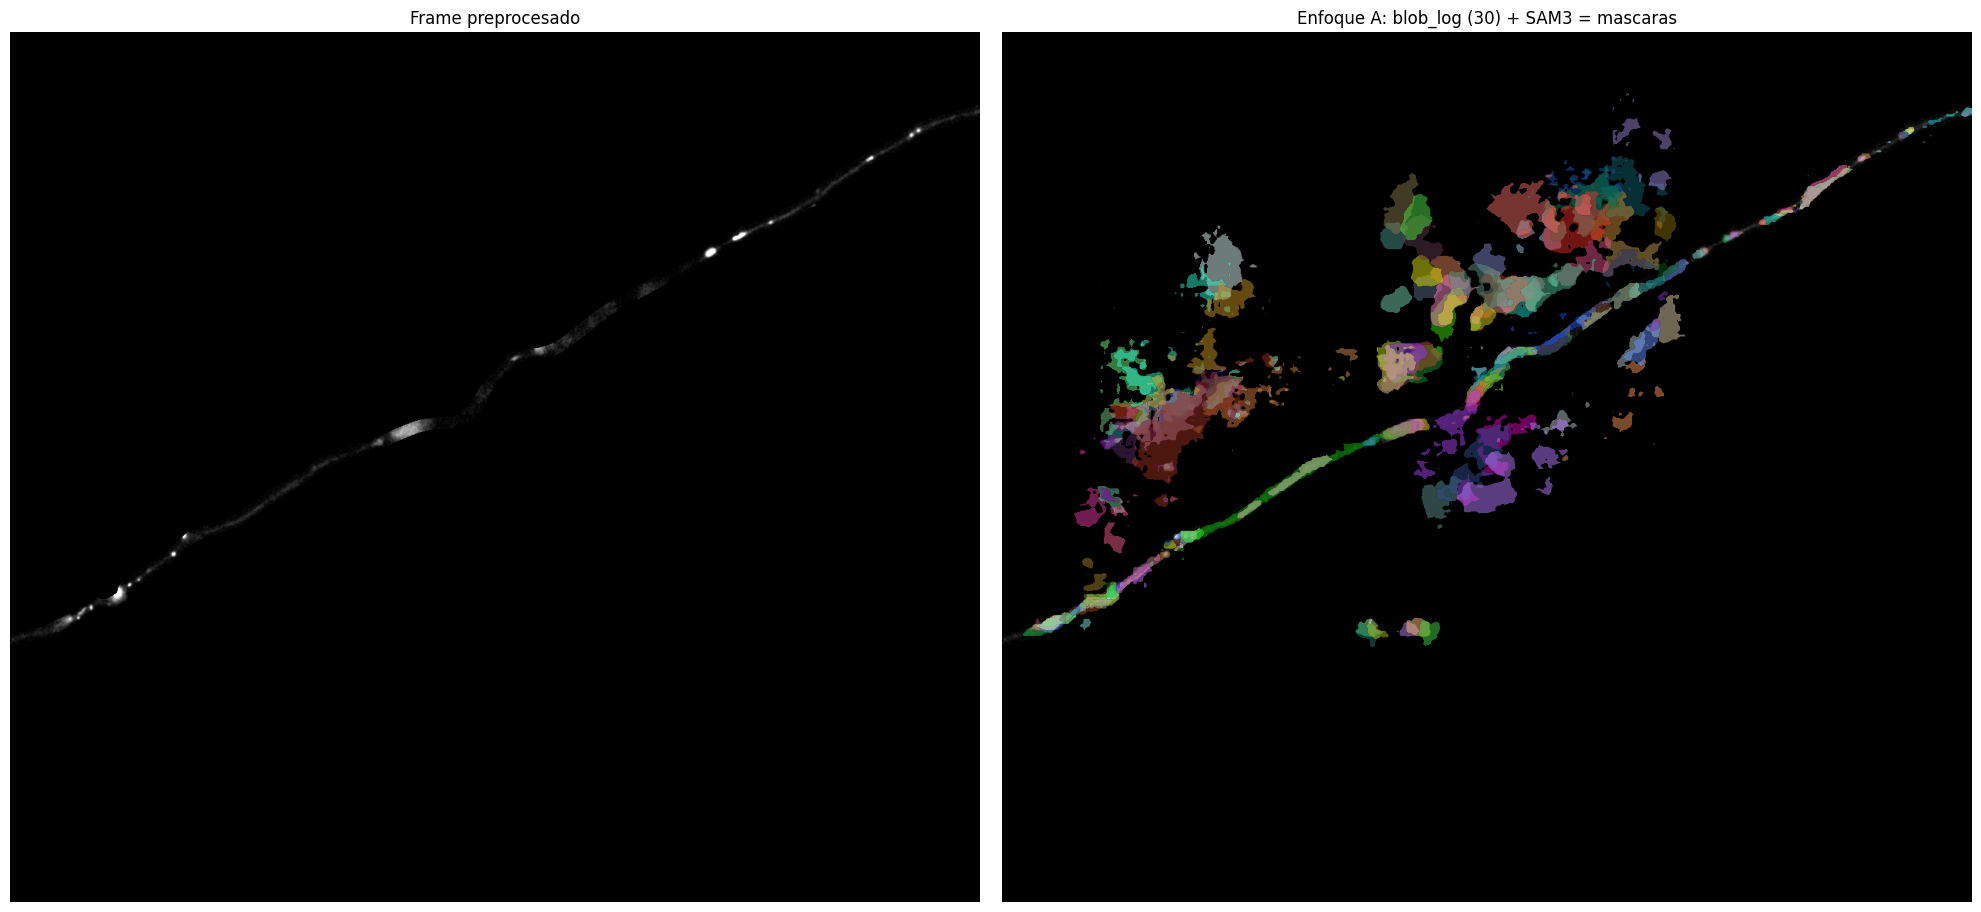

In [4]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(20, 9))
viz.mostrar_frame(frame_rgb, "Frame preprocesado", ax=ax0)
viz.overlay_mascaras(frame_rgb, m_arr_a, ax=ax1)
ax1.set_title(f"Enfoque A: blob_log ({len(blobs_top)}) + SAM3 = mascaras")
plt.tight_layout()
plt.show()

---

## Enfoque B — Grounding DINO + SAM3

El "Grounded SAM" clásico, pero con SAM3 como segmentador. Sirve de **referencia** contra el Enfoque C: vamos a ver si SAM3 con texto directo le gana a este pipeline en dos pasos.


In [5]:
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection

DINO_ID = "IDEA-Research/grounding-dino-tiny"
print(f"Cargando {DINO_ID}...")
processor_dino = AutoProcessor.from_pretrained(DINO_ID)
model_dino = (
    AutoModelForZeroShotObjectDetection.from_pretrained(DINO_ID).to(device).eval()
)
print("OK")

Cargando IDEA-Research/grounding-dino-tiny...


Loading weights:   0%|          | 0/978 [00:00<?, ?it/s]

OK


In [6]:
TEXTO_DINO = "small fluorescent particle."

inputs_dino = processor_dino(images=frame_pil, text=TEXTO_DINO, return_tensors="pt").to(
    device
)
with torch.no_grad():
    outputs_dino = model_dino(**inputs_dino)

resultados_dino = processor_dino.post_process_grounded_object_detection(
    outputs_dino,
    inputs_dino.input_ids,
    threshold=0.20,
    text_threshold=0.20,
    target_sizes=[(frame_pil.size[1], frame_pil.size[0])],
)[0]
boxes_dino = resultados_dino["boxes"].cpu().numpy()
scores_dino = resultados_dino["scores"].cpu().numpy()
print(f'Grounding DINO con "{TEXTO_DINO}": {len(boxes_dino)} cajas.')

if len(boxes_dino) > 0:
    input_boxes_b = [boxes_dino.tolist()]
    inputs_b = processor_sam3(
        images=frame_pil,
        input_boxes=input_boxes_b,
        return_tensors="pt",
    ).to(device)
    with torch.no_grad():
        outputs_b = model_sam3(**inputs_b)

    resultados_b = processor_sam3.post_process_instance_segmentation(
        outputs_b,
        threshold=0.0,  # una mascara por caja
        target_sizes=[(frame_pil.size[1], frame_pil.size[0])],
    )[0]
    m_arr_b = resultados_b.get("masks", None)
    if m_arr_b is not None and hasattr(m_arr_b, "cpu"):
        m_arr_b = m_arr_b.cpu().numpy()
    elif m_arr_b is None:
        m_arr_b = np.zeros((0, *frame_rgb.shape[:2]), dtype=bool)
else:
    m_arr_b = np.zeros((0, *frame_rgb.shape[:2]), dtype=bool)

print(f"SAM3 sobre cajas de DINO: {len(m_arr_b)} mascaras.")

Grounding DINO con "small fluorescent particle.": 2 cajas.
SAM3 sobre cajas de DINO: 200 mascaras.


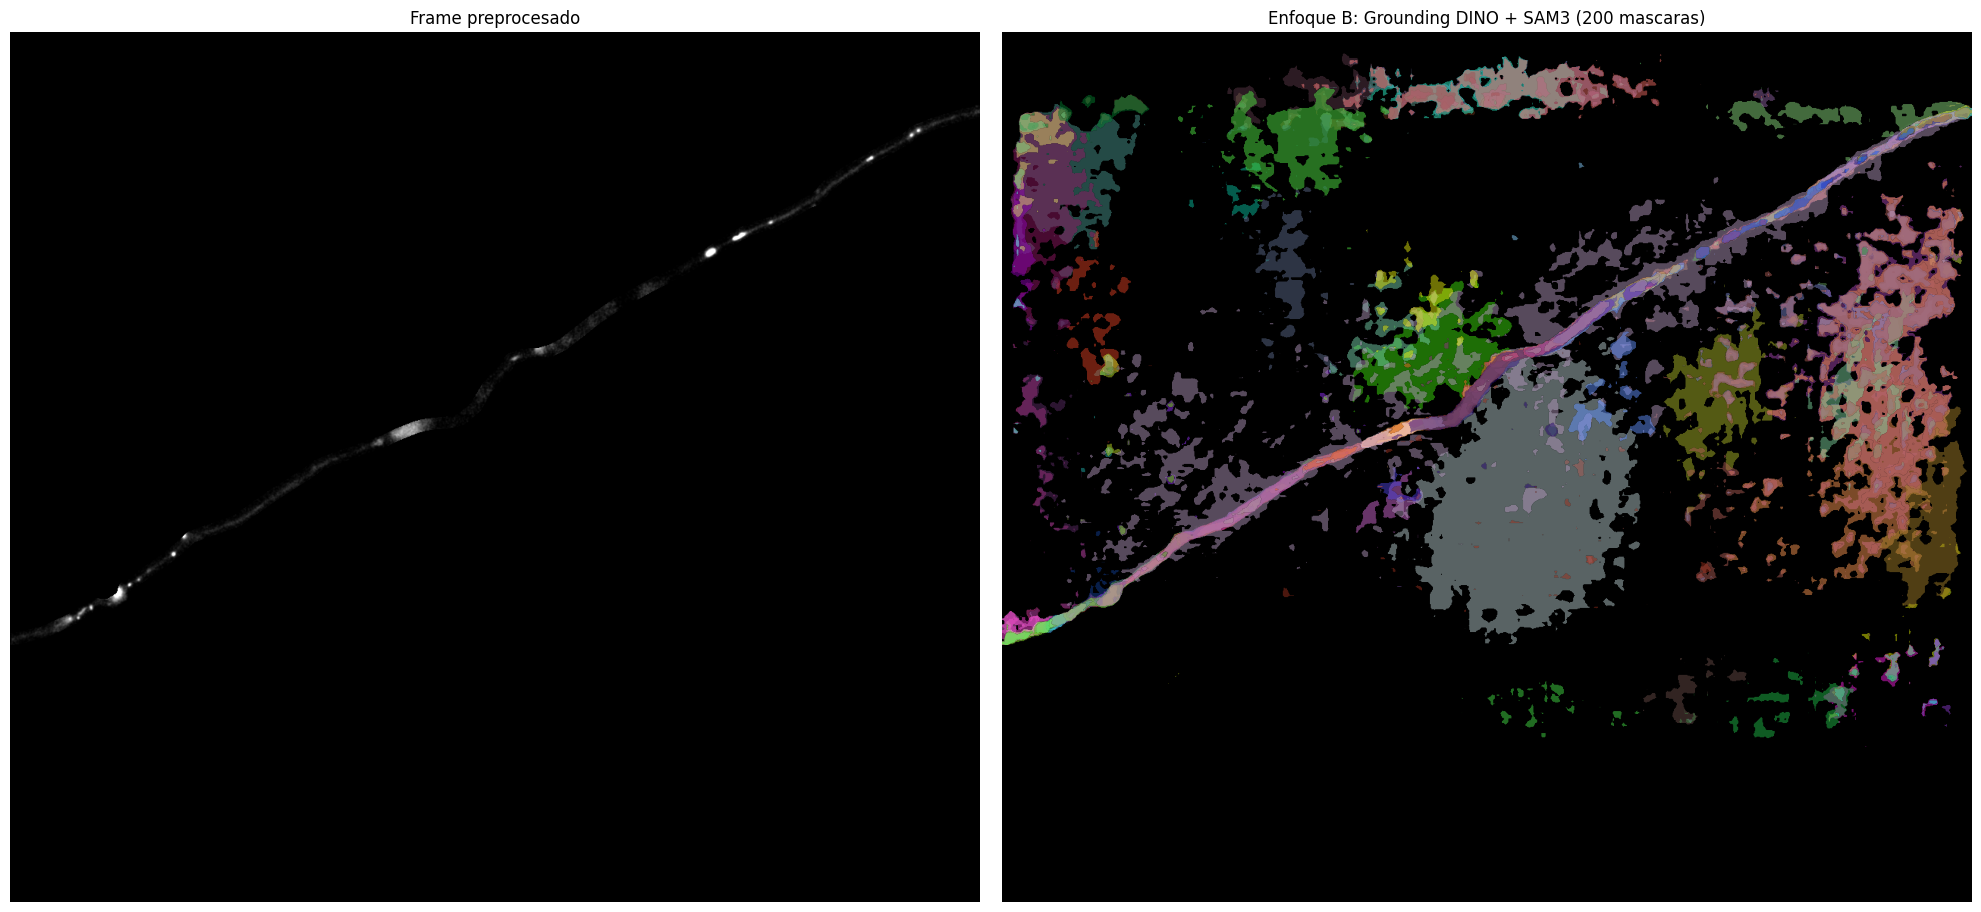

In [7]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(20, 9))
viz.mostrar_frame(frame_rgb, "Frame preprocesado", ax=ax0)
viz.overlay_mascaras(frame_rgb, m_arr_b, ax=ax1)
ax1.set_title(f"Enfoque B: Grounding DINO + SAM3 ({len(m_arr_b)} mascaras)")
plt.tight_layout()
plt.show()

---

## Enfoque C — SAM3 con texto directo (la novedad)

Acá está la **diferencia fundamental con SAM2**. Le pasamos al modelo la imagen + texto, y devuelve directamente una lista de instancias con sus máscaras y scores. **Sin detector externo.**

Vamos a probar 3 frases ("queries") para ver cuál responde mejor:


In [8]:
TEXT_QUERIES = [
    "small bright dot",
    "fluorescent particle",
    "vesicle",
]
SCORE_THRESHOLD = 0.3


def detectar_con_texto(image_pil, text):
    """SAM3 con prompt de texto -> mascaras + scores de cada instancia."""
    inputs = processor_sam3(images=image_pil, text=text, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model_sam3(**inputs)
    target_size = [(image_pil.size[1], image_pil.size[0])]
    resultados = processor_sam3.post_process_instance_segmentation(
        outputs,
        threshold=SCORE_THRESHOLD,
        target_sizes=target_size,
    )[0]
    return resultados.get("masks", None), resultados.get("scores", None)


detecciones_c = {}
for q in TEXT_QUERIES:
    masks, scores = detectar_con_texto(frame_pil, q)
    n = 0 if masks is None else len(masks)
    detecciones_c[q] = (masks, scores)
    print(f'  "{q}" -> {n} instancias (score >= {SCORE_THRESHOLD})')

  "small bright dot" -> 8 instancias (score >= 0.3)
  "fluorescent particle" -> 3 instancias (score >= 0.3)
  "vesicle" -> 0 instancias (score >= 0.3)


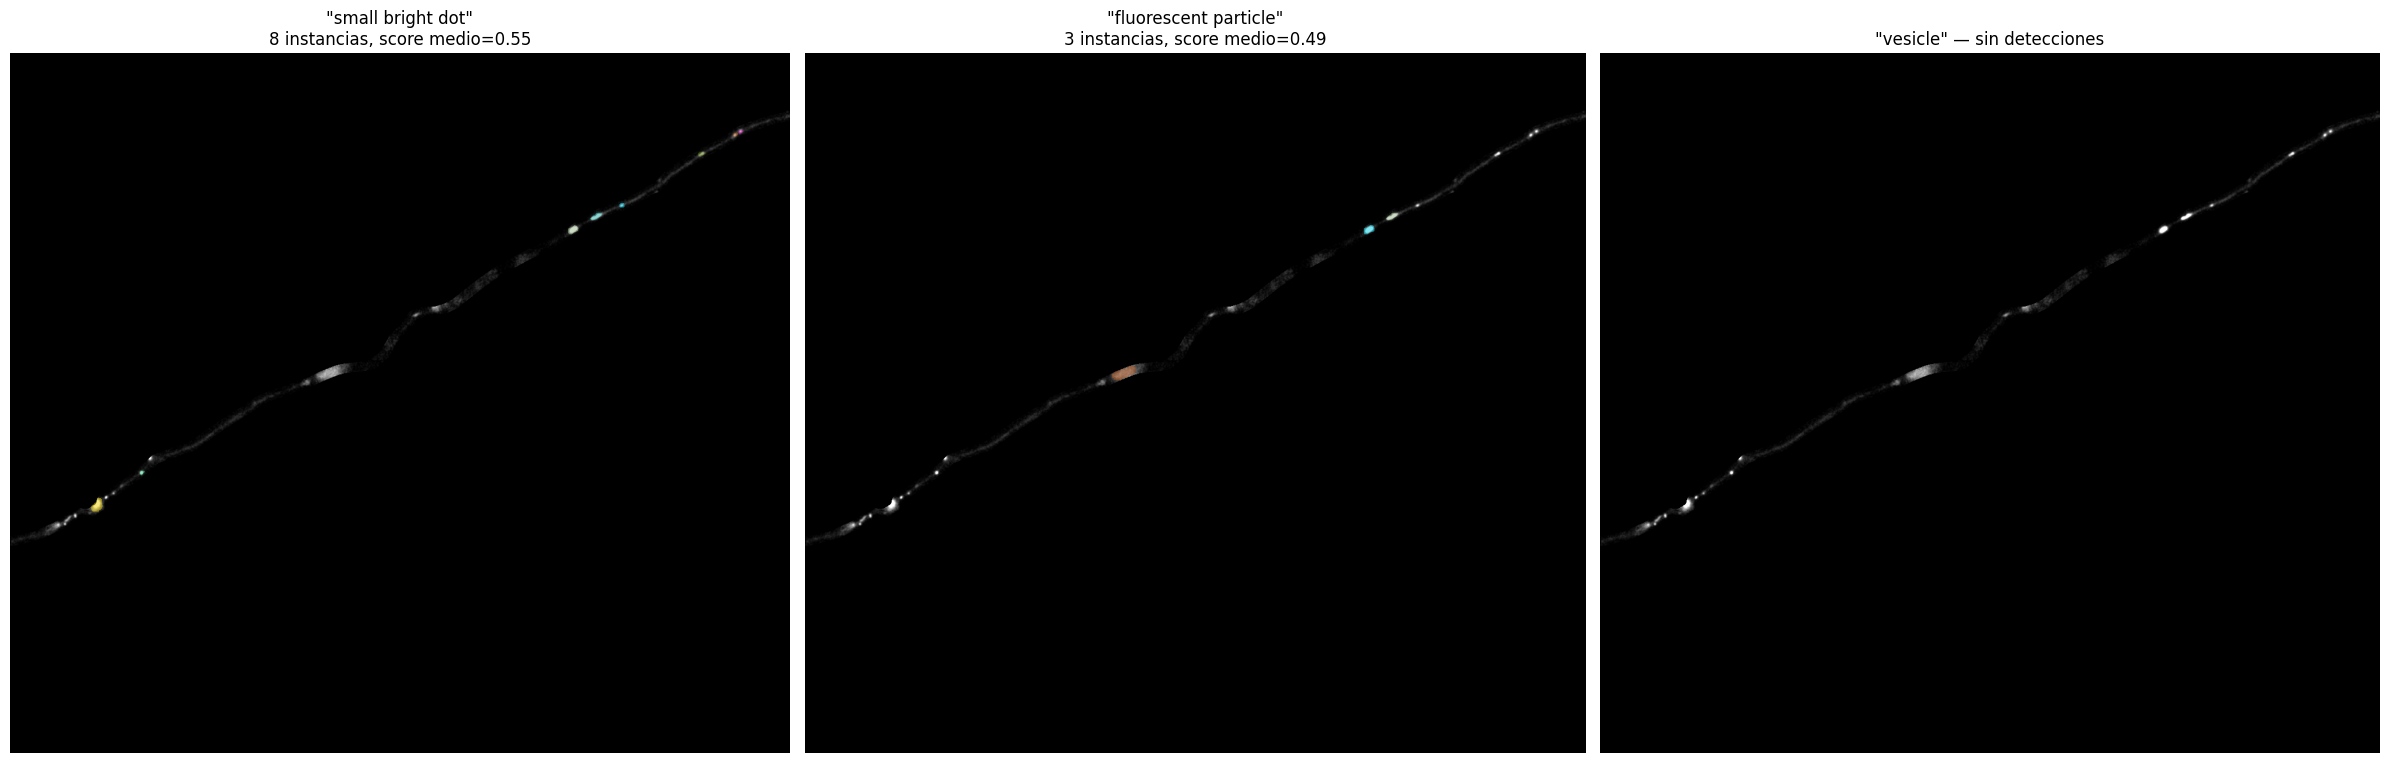

In [9]:
# Visualizacion en grid: una columna por query.
fig, axes = plt.subplots(1, len(TEXT_QUERIES), figsize=(8 * len(TEXT_QUERIES), 8))
if len(TEXT_QUERIES) == 1:
    axes = [axes]
for ax, q in zip(axes, TEXT_QUERIES):
    masks, scores = detecciones_c[q]
    if masks is None or len(masks) == 0:
        viz.mostrar_frame(frame_rgb, f'"{q}" — sin detecciones', ax=ax)
    else:
        viz.overlay_mascaras(frame_rgb, masks, ax=ax)
        s_mean = float(scores.mean()) if scores is not None and len(scores) else 0.0
        ax.set_title(f'"{q}"\n{len(masks)} instancias, score medio={s_mean:.2f}')
plt.tight_layout()
plt.show()

**Lectura de los resultados del Enfoque C:**

- **"small bright dot"** suele ser el más **permisivo** — encuentra muchas cosas pero también mezcla falsos positivos (agregados grandes que no son vesículas).
- **"fluorescent particle"** es más **conservador** — menos detecciones pero suele preferir blobs más grandes.
- **"vesicle"** suele devolver **cero** — SAM3 fue entrenado en imágenes naturales, no entiende el concepto biológico de "vesícula".

Esto es **informativo**: SAM3 sirve como detector general de "manchas brillantes" pero no como detector semántico de un concepto biológico específico.


---

## Comparación: B (Grounding DINO + SAM3) vs C (SAM3 con texto)

Acá está la pregunta clave: **¿el modelo unificado (C) le gana al pipeline en dos pasos (B)?**


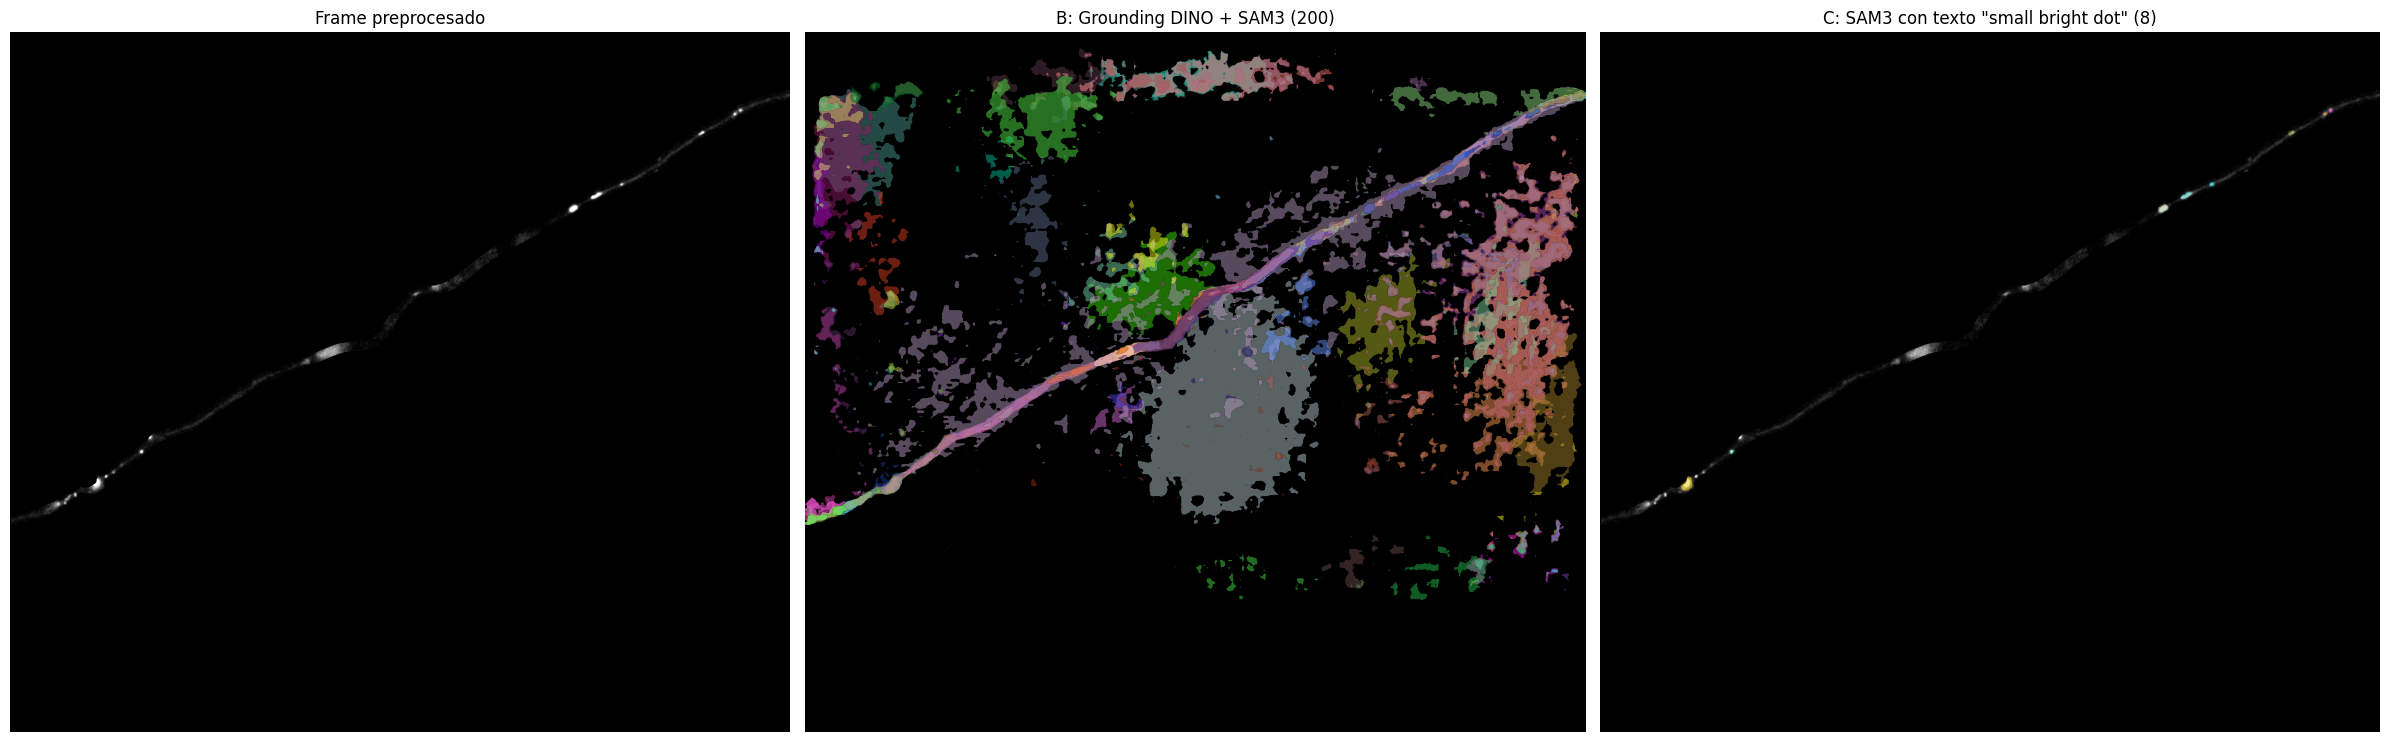

In [10]:
# Tomamos la mejor query del enfoque C para la comparacion (asumimos "small bright dot").
query_c = "small bright dot"
masks_c, scores_c = detecciones_c[query_c]

fig, axes = plt.subplots(1, 3, figsize=(24, 8))
viz.mostrar_frame(frame_rgb, "Frame preprocesado", ax=axes[0])
viz.overlay_mascaras(frame_rgb, m_arr_b, ax=axes[1])
axes[1].set_title(f"B: Grounding DINO + SAM3 ({len(m_arr_b)})")
if masks_c is not None and len(masks_c) > 0:
    viz.overlay_mascaras(frame_rgb, masks_c, ax=axes[2])
axes[2].set_title(
    f'C: SAM3 con texto "{query_c}" ({0 if masks_c is None else len(masks_c)})'
)
plt.tight_layout()
plt.show()

**Observación esperada:** el Enfoque C (SAM3 unificado) suele detectar **más instancias** y con **máscaras más prolijas** que el Enfoque B (DINO + SAM3 separados). Esto pasa porque SAM3 fue entrenado _end-to-end_ para detección+segmentación, mientras que DINO + SAM3 son dos modelos que no comparten representaciones. La diferencia se nota especialmente en escenas con muchas instancias pequenias.


---

## Comparación con el notebook 02 (SAM2 vs SAM3)

Si corriste también [02_sam2_prototipo.ipynb](02_sam2_prototipo.ipynb), vale la pena comparar:

| Métrica                                       | SAM2             | SAM3                        |
| --------------------------------------------- | ---------------- | --------------------------- |
| Calidad de máscaras (Enfoque A, mismos blobs) | similar          | similar o ligeramente mejor |
| Cantidad de detecciones con texto             | N/A (no soporta) | varias decenas              |
| Velocidad                                     | ~1.5x más rápido | más lento (más parámetros)  |
| Tamanio del modelo                            | ~325 MB          | varios GB                   |

**Para este caso de uso (vesículas chicas en microscopía):**

- Ambos sufren con vesículas de 2–3 px porque están fuera de su distribución de entrenamiento.
- SAM3 abre la posibilidad de prompts de texto, lo cual es útil para prototipar sin etiquetar datos.
- La diferencia real va a aparecer cuando se combine con un **detector específico fine-tuneado** (ej: YOLO11 entrenado en 100 vesículas a mano). En ese escenario, SAM2 y SAM3 dan resultados de calidad similar; la elección depende más de velocidad y tamanio.


---

## Próximos pasos

1. **Tracking en video con SAM3-video**: extender el Enfoque C a un video completo. SAM3 tiene un modo video que propaga las máscaras del frame 0 a los siguientes manteniendo identidad.
2. **Tunear los queries de texto**: probar más frases (`"axonal transport granule"`, `"bright punctum"`, etc.) para ver cuál mapea mejor al concepto de vesícula.
3. **Cuantificación**: medir velocidades en µm/s usando [parametros.py](../src/axonal_tracking/parametros.py) y comparar contra el ground truth manual.
4. **Aplicar la máscara del ROI a posteriori**: filtrar las detecciones que cayeron fuera del axón. Es una mejora ortogonal a cualquier enfoque (A, B, C).
